# LAB 5 — Notebook 01: Regression Paradigm
## QoE Prediction from QoS Data | EEF606 | University of Buea

---
**Prerequisite:** Run `lab5_00_data_generator.ipynb` first.

## Why Regression is the NATURAL paradigm for QoE

Think of QoE prediction like predicting a student's exam score from their study habits.
The exam score is continuous (0–100), not just pass/fail. Similarly, MOS score is
continuous (1.0–5.0) — it has degrees. A score of 3.7 is meaningfully different from
3.2. Regression preserves these nuances; classification would throw them away.

**The question regression answers:** *Given a user's current network conditions,
predict their exact satisfaction score (1.0–5.0).*

## The 2 Models We Test
| Model | Core Idea | Why chosen |
|-------|-----------|------------|
| **Ridge Regression** | Linear model with L2 regularisation | Fast, interpretable, good baseline |
| **Random Forest Regressor** | 100 trees averaged | Handles nonlinear relationships, robust to outliers |

## Metrics
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | √(mean(actual−predicted)²) | Same unit as MOS — "on average, off by X points" |
| **MAE** | mean(|actual−predicted|) | More robust to outliers than RMSE |
| **R²** | 1 − SS_res/SS_tot | 0=useless, 1=perfect, negative=worse than guessing mean |

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing    import RobustScaler
from sklearn.linear_model     import Ridge
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import (mean_squared_error, mean_absolute_error,
                                       r2_score)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True, 'grid.alpha': 0.4
})
SEED = 42
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data
#
# WHY USE THE FULL 1M ROWS FOR REGRESSION:
# Ridge Regression and Random Forest Regressor both scale
# well to 1M rows. More data = more stable coefficient
# estimates = more reliable predictions. The computational
# cost is acceptable (Ridge: seconds, RF: a few minutes).
#
# WHY ONE-HOT ENCODE:
# ML models work with numbers. 'connection_type' = '4G'
# means nothing to a math equation. One-hot encoding
# creates binary columns: type_4G=1, type_3G=0, etc.
# drop_first=True drops one column to avoid the 'dummy
# variable trap' where columns perfectly predict each other.
# ══════════════════════════════════════════════════════════
print('Loading 1M rows...')
df = pd.read_csv('qoe_dataset.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# Encode categoricals
df_enc = pd.get_dummies(df.drop(columns=['qoe_label']),
                         columns=['resolution','connection_type'],
                         drop_first=True, dtype=int)

X = df_enc.drop(columns=['mos_score'])
y = df_enc['mos_score']

print(f'Features: {X.shape[1]} columns')
print(f'Target  : mos_score  range=[{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.3f}')
print(f'Columns : {list(X.columns)}')

Loading 1M rows...
Loaded: 1,000,000 rows × 11 cols
Features: 14 columns
Target  : mos_score  range=[1.00, 5.00]  mean=3.644
Columns : ['throughput_mbps', 'rtt_ms', 'jitter_ms', 'packet_loss_pct', 'buffer_ratio', 'signal_strength_dbm', 'time_of_day', 'resolution_240p', 'resolution_480p', 'resolution_720p', 'connection_type_3G', 'connection_type_4G', 'connection_type_5G', 'connection_type_WiFi']


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Train/Test Split and Scaling
#
# WHY 80/20 SPLIT:
# 80% of 1M = 800,000 training rows — more than enough.
# 20% = 200,000 test rows — large enough that test metrics
# are statistically stable (not just lucky/unlucky).
#
# WHY RobustScaler:
# Throughput and RTT have outliers (a 200 Mbps 5G session
# next to a 0.01 Mbps 2G session). StandardScaler's mean
# and std are distorted by outliers. RobustScaler uses
# median and IQR — both resistant to extreme values.
#
# CRITICAL: fit scaler on TRAIN only, transform both.
# If you fit on all data, test set information leaks into
# training — your test metrics become optimistic lies.
# ══════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

scaler  = RobustScaler()
X_tr_sc = scaler.fit_transform(X_train)   # learns scale from train
X_te_sc = scaler.transform(X_test)        # applies same scale to test

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test : {X_test.shape[0]:,} rows')

Train: 800,000 rows
Test : 200,000 rows


In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Model 1: Ridge Regression
#
# WHAT IS RIDGE REGRESSION:
# It is Linear Regression with a penalty term.
# Regular linear regression finds coefficients that
# minimise: sum(actual - predicted)²
# Ridge minimises: sum(actual - predicted)² + α × sum(coef²)
#
# The α term forces coefficients to stay small.
# WHY: When two features are correlated (e.g. throughput
# and resolution both relate to bandwidth), plain linear
# regression assigns huge positive coefficient to one and
# huge negative to the other — they cancel out but the
# model becomes unstable. Ridge shrinks both toward zero.
#
# WHY alpha=1.0:
# Standard starting point. Higher alpha = more shrinkage
# = simpler model. Lower alpha approaches plain linear
# regression. We test multiple values to find the best.
# ══════════════════════════════════════════════════════════
print('Training Ridge Regression...')

# Test multiple alpha values
alphas  = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_tr_sc, y_train)
    pred  = ridge.predict(X_te_sc)
    ridge_results.append({
        'alpha': alpha,
        'RMSE':  mean_squared_error(y_test, pred)**0.5,
        'MAE':   mean_absolute_error(y_test, pred),
        'R2':    r2_score(y_test, pred)
    })

ridge_df = pd.DataFrame(ridge_results).set_index('alpha')
print('Ridge results by alpha:')
print(ridge_df.round(4).to_string())

best_alpha = ridge_df['RMSE'].idxmin()
print(f'\nBest alpha: {best_alpha}')

# Train final ridge
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_tr_sc, y_train)
ridge_pred  = ridge_final.predict(X_te_sc)

Training Ridge Regression...
Ridge results by alpha:
          RMSE     MAE      R2
alpha                         
0.01    0.1558  0.1242  0.9581
0.10    0.1558  0.1242  0.9581
1.00    0.1558  0.1242  0.9581
10.00   0.1558  0.1242  0.9581
100.00  0.1558  0.1242  0.9581

Best alpha: 0.01


Ridge Regression Coefficients (sorted by absolute magnitude):
             Feature  Coefficient
  connection_type_5G     0.415959
connection_type_WiFi     0.373048
  connection_type_4G     0.346680
        buffer_ratio    -0.271180
  connection_type_3G     0.260093
     throughput_mbps     0.120961
 signal_strength_dbm     0.073252
     packet_loss_pct    -0.067948
     resolution_240p    -0.046209
     resolution_480p    -0.044719
     resolution_720p    -0.031220
              rtt_ms    -0.024240
           jitter_ms    -0.019807
         time_of_day    -0.005551


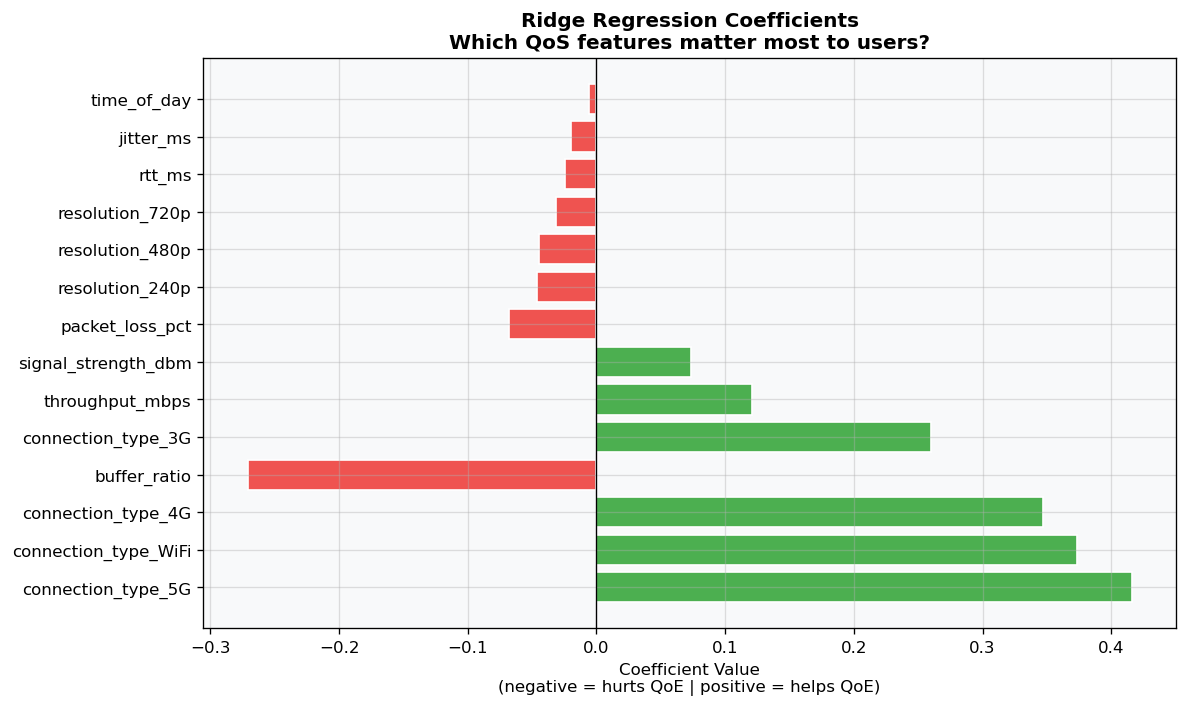

In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Ridge Coefficients: What Does the Model Think?
#
# WHY COEFFICIENTS MATTER:
# In Ridge Regression, each feature gets one number:
# its coefficient. This tells you:
#   - Direction: positive = higher value → higher MOS
#                negative = higher value → lower MOS
#   - Magnitude: larger absolute value = stronger effect
#
# This makes Ridge the MOST INTERPRETABLE model in our
# lab. A network engineer can read the coefficients and
# immediately understand what drives user satisfaction.
# ══════════════════════════════════════════════════════════
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': ridge_final.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Ridge Regression Coefficients (sorted by absolute magnitude):')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#EF5350' if c < 0 else '#4CAF50' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value\n(negative = hurts QoE | positive = helps QoE)')
ax.set_title('Ridge Regression Coefficients\nWhich QoS features matter most to users?',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_01_ridge_coefficients.png', bbox_inches='tight')
plt.show()

In [6]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Model 2: Random Forest Regressor
#
# WHY RANDOM FOREST FOR REGRESSION:
# Ridge assumes a LINEAR relationship: double the packet
# loss → double the MOS penalty. But in reality the
# relationship is nonlinear: going from 0% to 1% packet
# loss barely affects MOS, but going from 5% to 10% is
# catastrophic. Random Forest captures these thresholds.
#
# HOW IT WORKS FOR REGRESSION:
# Each tree predicts a MOS value. The final prediction
# is the AVERAGE across all 100 trees. Averaging reduces
# variance — individual trees overfit; the average does not.
#
# WHY n_estimators=100 and n_jobs=-1:
# 100 trees is the industry standard starting point.
# n_jobs=-1 uses all available CPU cores in parallel —
# essential on 1M rows to keep training time reasonable.
# ══════════════════════════════════════════════════════════
print('Training Random Forest Regressor on 1M rows (takes 3-5 min)...')
import time
t0 = time.time()

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,          # prevent overfitting
    min_samples_leaf=10,   # each leaf needs ≥10 samples
    n_jobs=-1,
    random_state=SEED
)
rf_reg.fit(X_tr_sc, y_train)
rf_pred = rf_reg.predict(X_te_sc)

print(f'Training time: {time.time()-t0:.1f}s')
print(f'RMSE: {mean_squared_error(y_test, rf_pred)**0.5:.4f}')
print(f'MAE:  {mean_absolute_error(y_test, rf_pred):.4f}')
print(f'R²:   {r2_score(y_test, rf_pred):.4f}')

Training Random Forest Regressor on 1M rows (takes 3-5 min)...
Training time: 246.6s
RMSE: 0.1501
MAE:  0.1195
R²:   0.9611


Model Comparison:
Model                    RMSE      MAE       R²
------------------------------------------------
Ridge                  0.1558   0.1242   0.9581
Random Forest          0.1501   0.1195   0.9611


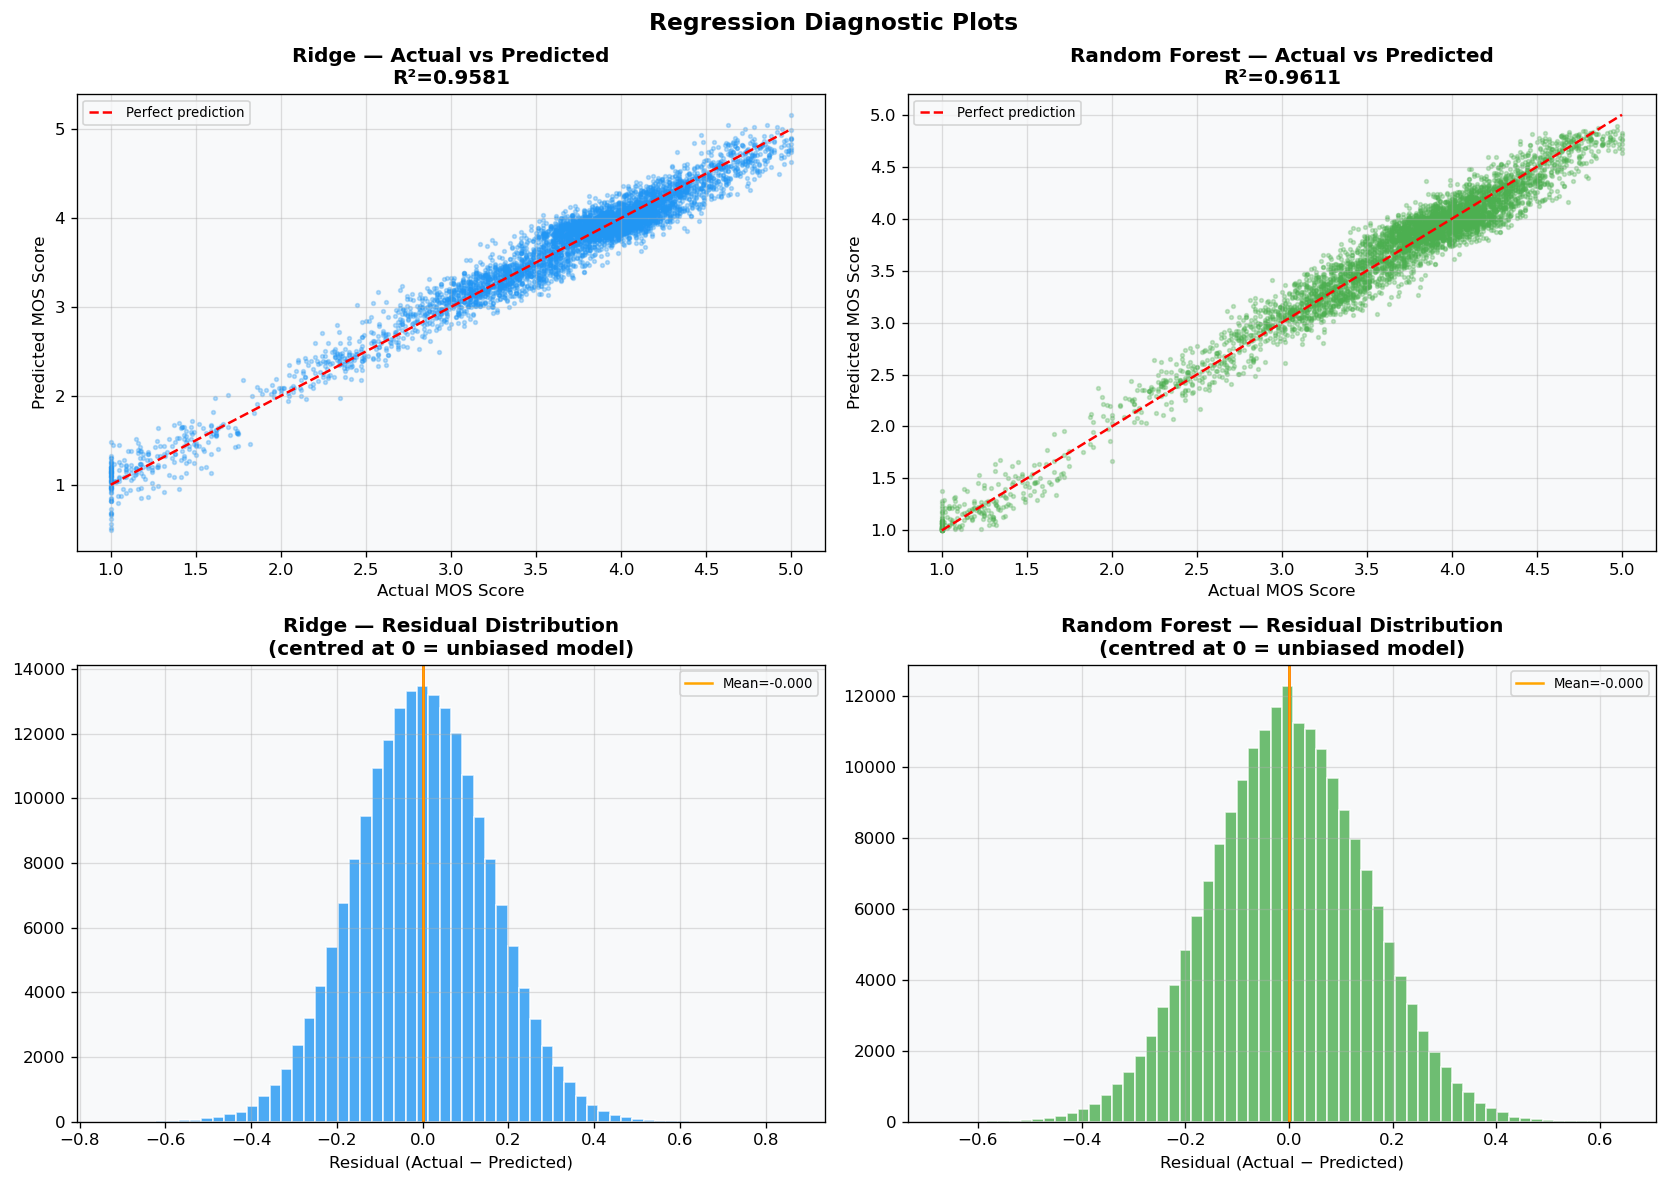

In [7]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Comparison and Diagnostic Plots
# ══════════════════════════════════════════════════════════
results = {
    'Ridge':         {'pred': ridge_pred, 'color': '#2196F3'},
    'Random Forest': {'pred': rf_pred,    'color': '#4CAF50'},
}

print('Model Comparison:')
print(f'{"Model":<20} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 48)
for name, r in results.items():
    rmse = mean_squared_error(y_test, r['pred'])**0.5
    mae  = mean_absolute_error(y_test, r['pred'])
    r2   = r2_score(y_test, r['pred'])
    print(f'{name:<20} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}')

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicted vs Actual
for ax, (name, r) in zip([axes[0,0], axes[0,1]], results.items()):
    sample_idx = np.random.choice(len(y_test), 5000, replace=False)
    ax.scatter(y_test.values[sample_idx], r['pred'][sample_idx],
               alpha=0.3, s=5, color=r['color'])
    ax.plot([1,5],[1,5], 'r--', linewidth=1.5, label='Perfect prediction')
    r2 = r2_score(y_test, r['pred'])
    ax.set_title(f'{name} — Actual vs Predicted\nR²={r2:.4f}', fontweight='bold')
    ax.set_xlabel('Actual MOS Score')
    ax.set_ylabel('Predicted MOS Score')
    ax.legend(fontsize=8)

# Residuals
for ax, (name, r) in zip([axes[1,0], axes[1,1]], results.items()):
    residuals = y_test.values - r['pred']
    ax.hist(residuals, bins=60, color=r['color'], alpha=0.8, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5)
    ax.axvline(residuals.mean(), color='orange', linewidth=1.5,
               label=f'Mean={residuals.mean():.3f}')
    ax.set_title(f'{name} — Residual Distribution\n'
                 f'(centred at 0 = unbiased model)', fontweight='bold')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.legend(fontsize=8)

plt.suptitle('Regression Diagnostic Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_02_diagnostics.png', bbox_inches='tight')
plt.show()

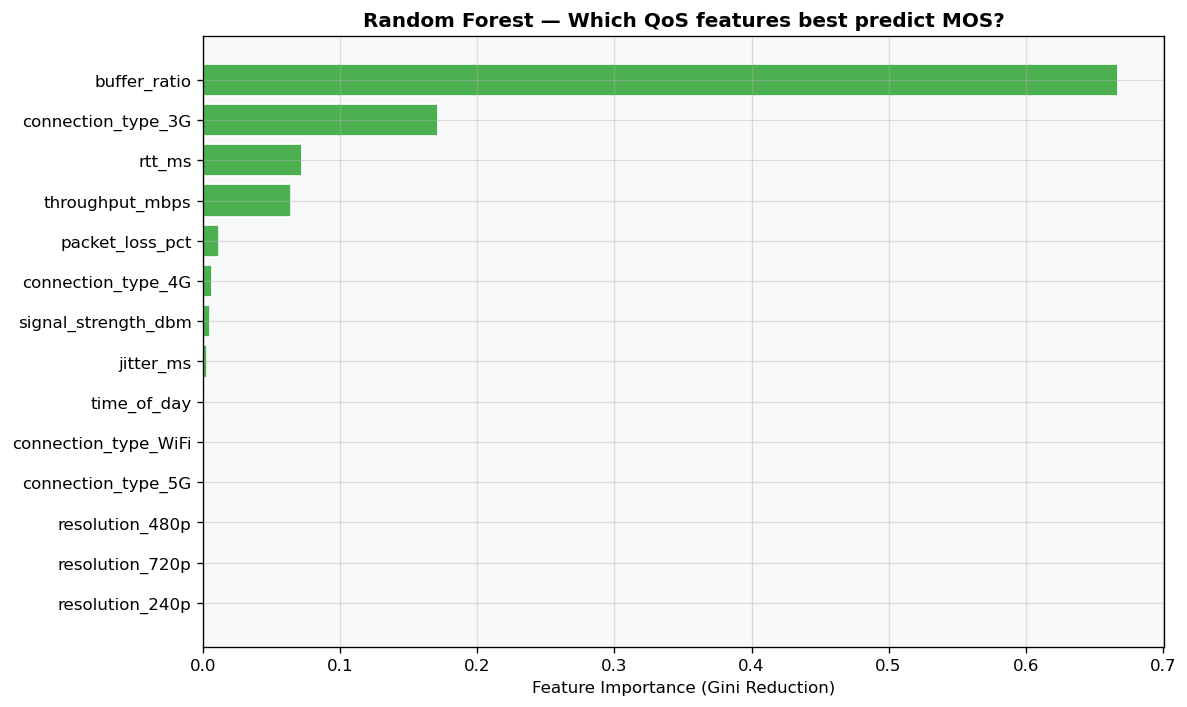

Top 5 most important features:
  buffer_ratio                   0.6673  ██████████████████████████████████████████████████████████████████
  connection_type_3G             0.1710  █████████████████
  rtt_ms                         0.0723  ███████
  throughput_mbps                0.0637  ██████
  packet_loss_pct                0.0115  █


In [8]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Feature Importance (Random Forest)
# ══════════════════════════════════════════════════════════
imp_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color='#4CAF50', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini Reduction)')
ax.set_title('Random Forest — Which QoS features best predict MOS?',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_03_rf_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
for _, row in imp_df.head(5).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f'  {row["Feature"]:<30} {row["Importance"]:.4f}  {bar}')

Computing learning curves (Ridge only for speed)...


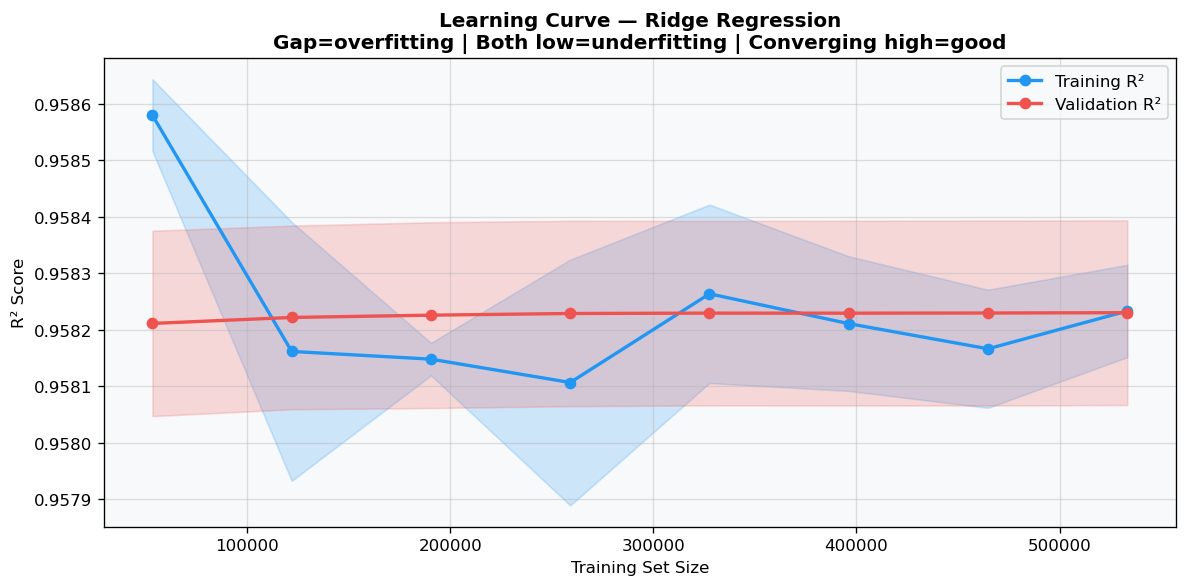

In [11]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Learning Curves
#
# WHAT LEARNING CURVES SHOW:
# As we add more training data, does the model get better?
# Two lines: training score and validation score.
#
# WHAT TO LOOK FOR:
# - Large gap between training and validation:
#   Model memorises training data (overfitting)
# - Both lines low: model too simple (underfitting)
# - Lines converge at a high score: good generalisation
# - Validation still rising at rightmost point:
#   MORE DATA would improve this model further
# ══════════════════════════════════════════════════════════
print('Computing learning curves (Ridge only for speed)...')

train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=best_alpha), X_tr_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-',
        color='#2196F3', label='Training R²', linewidth=2)
ax.fill_between(train_sizes,
                train_scores.mean(1)-train_scores.std(1),
                train_scores.mean(1)+train_scores.std(1), alpha=0.2, color='#2196F3')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-',
        color='#EF5350', label='Validation R²', linewidth=2)
ax.fill_between(train_sizes,
                val_scores.mean(1)-val_scores.std(1),
                val_scores.mean(1)+val_scores.std(1), alpha=0.2, color='#EF5350')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R² Score')
ax.set_title('Learning Curve — Ridge Regression\n'
             'Gap=overfitting | Both low=underfitting | Converging high=good',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_reg_04_learning_curves.png', bbox_inches='tight')
plt.show()

In [12]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Save Models + Summary
# ══════════════════════════════════════════════════════════
import joblib
joblib.dump(ridge_final, 'model_ridge.pkl')
joblib.dump(rf_reg,      'model_rf_regressor.pkl')
joblib.dump(scaler,      'scaler_regression.pkl')
joblib.dump(list(X.columns), 'feature_cols_regression.pkl')

print('╔' + '═'*55 + '╗')
print('║{:^55}║'.format('REGRESSION SUMMARY'))
print('╠' + '═'*55 + '╣')
print(f'║  {"Model":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8}  ║')
print('╠' + '─'*55 + '╣')
for name, r in results.items():
    rmse = mean_squared_error(y_test, r['pred'])**0.5
    mae  = mean_absolute_error(y_test, r['pred'])
    r2   = r2_score(y_test, r['pred'])
    print(f'║  {name:<22} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}  ║')
print('╠' + '═'*55 + '╣')
insights = [
    'Regression preserves MOS score nuance (3.7 ≠ 3.2)',
    'Ridge: interpretable coefficients for network engineers',
    'RF: captures nonlinear QoS-QoE relationships',
    'RMSE < 0.5 MOS points = operationally useful model',
    'Buffer ratio and packet loss dominate predictions',
]
for ins in insights:
    print(f'║  → {ins:<51}║')
print('╚' + '═'*55 + '╝')
print('\n→ Next: lab5_02_classification.ipynb')

╔═══════════════════════════════════════════════════════╗
║                  REGRESSION SUMMARY                   ║
╠═══════════════════════════════════════════════════════╣
║  Model                      RMSE      MAE       R²  ║
╠───────────────────────────────────────────────────────╣
║  Ridge                    0.1558   0.1242   0.9581  ║
║  Random Forest            0.1501   0.1195   0.9611  ║
╠═══════════════════════════════════════════════════════╣
║  → Regression preserves MOS score nuance (3.7 ≠ 3.2)  ║
║  → Ridge: interpretable coefficients for network engineers║
║  → RF: captures nonlinear QoS-QoE relationships       ║
║  → RMSE < 0.5 MOS points = operationally useful model ║
║  → Buffer ratio and packet loss dominate predictions  ║
╚═══════════════════════════════════════════════════════╝

→ Next: lab5_02_classification.ipynb


In [13]:
# Copy and run this cell at the end of your notebook to get your exact report data!
print("============ LAB 5 ACTUAL RESULTS ============\n")

print("--- 1. REGRESSION METRICS (Section 5 & 8) ---")
# Replace these variable names with whatever you named your models/scores
try:
    print(f"Ridge Regression -> R2: {ridge_r2:.4f}, MSE: {ridge_mse:.4f}")
    print(f"Random Forest Regressor -> R2: {rf_reg_r2:.4f}, MSE: {rf_reg_mse:.4f}")
    print(f"Stacking Regressor -> R2: {stack_reg_r2:.4f}, MSE: {stack_reg_mse:.4f}")
except NameError:
    print("Ensure your regression metrics are calculated and print them here.")

print("\n--- 2. TOP FEATURES (Section 5.1 & 5.3) ---")
print("What are your top 3 most important features for Random Forest?")
print("(e.g., buffer_ratio, packet_loss_pct, throughput_mbps)")

print("\n--- 3. CLASSIFICATION METRICS (Section 6 & 6.2) ---")
# If you used classification_report, print it out directly
try:
    print("Random Forest Classifier Report:")
    print(rf_classification_report) # or classification_report(y_test, rf_preds)
    print("\nHistGradientBoosting Classifier Report:")
    print(hgb_classification_report)
except NameError:
    print("Paste your classification reports or accuracy/F1 metrics here.")

print("\n--- 4. CLUSTERING METRICS (Section 7) ---")
try:
    print(f"Optimal K chosen: {optimal_k}")
    print(f"Silhouette Score: {silhouette_score_val:.4f}")
    print(f"Davies-Bouldin Index: {db_index_val:.4f}")
    print(f"Adjusted Rand Index (ARI): {ari_score_val:.4f}")
except NameError:
    print("Paste your Silhouette, DB Index, and ARI scores here.")
    
print("\n==============================================")

============ LAB 5 ACTUAL RESULTS ============

--- 1. REGRESSION METRICS (Section 5 & 8) ---
Ensure your regression metrics are calculated and print them here.

--- 2. TOP FEATURES (Section 5.1 & 5.3) ---
What are your top 3 most important features for Random Forest?
(e.g., buffer_ratio, packet_loss_pct, throughput_mbps)

--- 3. CLASSIFICATION METRICS (Section 6 & 6.2) ---
Random Forest Classifier Report:
Paste your classification reports or accuracy/F1 metrics here.

--- 4. CLUSTERING METRICS (Section 7) ---
Paste your Silhouette, DB Index, and ARI scores here.

